# Overview

In this module, we will inspect and explore the Training set part of the data (70% of samples). You can follow along and perform the same manipulations on the Testing set part of the data (30%) of samples.

Here are some of the topics covered in this part:
- matrix manipulations with Pandas
- exploring counts data
    - bar plots
    - heat maps
    - hierarchichal clustering
- pre-processing steps
    - log2 normalization (already performed)
    - scaling of data
- dimensional reduction
    - Principal Component Analysis

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)
from sklearn import preprocessing

# Import and Wrangle Data

In [5]:
probe_genes = pd.read_csv("probe_genes.csv")

In [6]:
train_labels = pd.read_csv("train_labels.csv", index_col=0)
train_counts = pd.read_csv("train_counts.csv", index_col=0)

## We can use Panda's .shape() and .head() to explore the dataframes

In [7]:
print(f"Shape of labels: {train_labels.shape}")
train_labels.head()

Shape of labels: (560, 1)


,Class
sample_154,LUAD
sample_770,BRCA
sample_738,LUAD
sample_627,BRCA
sample_258,PRAD


This contains metadata which tells us what tumor Class each sample is

In [8]:
print(f"Shape of counts: {train_counts.shape}")
train_counts.head()

Shape of counts: (560, 20531)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_154,0.0,1.682304,2.194434,6.347513,9.160572,0.0,5.799813,0.000000,0.0,0.0,...,5.853302,8.255392,9.658111,5.626311,10.399054,12.925274,10.341730,9.176400,5.356813,0.0000
sample_770,0.0,2.706995,3.574586,6.090422,9.557619,0.0,7.162452,0.467175,0.0,0.0,...,6.261474,9.005094,9.897212,6.405101,9.971630,12.057508,9.898369,9.835752,4.649144,0.0000
sample_738,0.0,2.716332,2.204391,6.078038,9.915415,0.0,6.759489,0.000000,0.0,0.0,...,5.791254,9.169572,9.992952,6.981316,9.639540,12.155590,10.431435,11.049365,7.733788,0.0000
sample_627,0.0,2.646347,3.194087,6.515042,9.739695,0.0,7.151849,0.803392,0.0,0.0,...,5.722149,8.819604,10.056245,7.709229,10.258472,10.953825,9.714965,10.018910,5.326275,0.0000
sample_258,0.0,3.143687,3.193772,6.461807,9.872566,0.0,6.517238,0.000000,0.0,0.0,...,6.318264,8.803343,9.960628,5.472342,9.586457,11.550862,10.184776,9.673095,6.218545,0.4654


This has the "counts" data for each sample. For example, Sample_154 had 9.16 "counts" for gene_4. These counts ctell us how many transcripts (RNA) of a given gene were present in the sample.

In [9]:
print(f"Shape of gene list {probe_genes.shape}")
probe_genes[5000:5010]

Shape of gene list (20531, 1)


,gene
5000,DLGAP3
5001,DLGAP4
5002,DLGAP5
5003,DLK1
5004,DLK2
5005,DLL1
5006,DLL3
5007,DLL4
5008,DLST
5009,DLX1


this dataframe has the same # of features as the counts matrix. Note how the column names of the counts matrix are just numbered genes. These are "probes", which target and count the transcripts (RNA) for each gene. We can use this list, which has the names of the genes, to make them the columns names of the dataframe.

## Add the tumor Class and gene names

In [10]:
#gene names have one duplicate
#remove duplicates in a very clunky manner. there is only one duplicate
while probe_genes.duplicated().value_counts()[False] != len(probe_genes):
    probe_genes[probe_genes.duplicated()]  = probe_genes[probe_genes.duplicated()] + "_duplicated"

In [11]:
train = train_counts.copy()
#this function makes it such that we can change this new dataframe without impacting the old one

#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.copy.html#pandas.DataFrame.copy
#read more about this. If you do not copy, you could inadvertantly edit a dataframe you do not want to change!!

In [12]:
#let's use the gene names and add them as the column names for the data
train.columns = probe_genes["gene"].to_list()

In [13]:
train.iloc[1:10, 11000:11005].head()

,MLYCD,MMAA,MMAB,MMACHC,MMADHC
sample_770,7.416080,8.348941,8.456506,6.815870,10.448695
sample_738,7.894424,7.911452,9.316628,7.301771,10.492124
sample_627,7.225535,8.409586,8.200747,7.074206,10.922592
sample_258,8.824090,7.737484,9.799879,7.571290,11.040851
sample_715,8.378897,7.559247,9.749957,6.898257,10.523111


In [14]:
#These genes are all in alphabetical order. We can also query specific genes:
train[["BRCA1", "BRCA2"]].head()

,BRCA1,BRCA2
sample_154,7.850993,6.348445
sample_770,8.469919,7.277157
sample_738,8.770614,6.750044
sample_627,9.405880,7.727097
sample_258,6.643455,4.598151


In [15]:
#lets also make a dataframe which contains the Class data. this will be useful for plotting later!
train_byclass = train.copy()
train_byclass.index = train_labels["Class"]

In [16]:
train_byclass.head()

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Class,,,,,,,,,,,,,,,,,,,,,
LUAD,0.0,1.682304,2.194434,6.347513,9.160572,0.0,5.799813,0.000000,0.0,0.0,...,5.853302,8.255392,9.658111,5.626311,10.399054,12.925274,10.341730,9.176400,5.356813,0.0000
BRCA,0.0,2.706995,3.574586,6.090422,9.557619,0.0,7.162452,0.467175,0.0,0.0,...,6.261474,9.005094,9.897212,6.405101,9.971630,12.057508,9.898369,9.835752,4.649144,0.0000
LUAD,0.0,2.716332,2.204391,6.078038,9.915415,0.0,6.759489,0.000000,0.0,0.0,...,5.791254,9.169572,9.992952,6.981316,9.639540,12.155590,10.431435,11.049365,7.733788,0.0000
BRCA,0.0,2.646347,3.194087,6.515042,9.739695,0.0,7.151849,0.803392,0.0,0.0,...,5.722149,8.819604,10.056245,7.709229,10.258472,10.953825,9.714965,10.018910,5.326275,0.0000
PRAD,0.0,3.143687,3.193772,6.461807,9.872566,0.0,6.517238,0.000000,0.0,0.0,...,6.318264,8.803343,9.960628,5.472342,9.586457,11.550862,10.184776,9.673095,6.218545,0.4654


To summarize, we have combined the following data:
- counts matrix for each sample
- tumor "Class" metadata for each sample
- gene names

Into two dataframes:
- "train"
    -this has Sample # on as rows and Gene Name as columns
- "train_byclass"
    -this has Class (tumor type) as rows and Gene Name as columns
    
Both will be useful for visualizations and making our classifier.

# Exploring the Data

## One gene's counts data

Lets focus on one gene of interest. you can choose one from the list:
- BRCA1

In [17]:
#*TODO* add more genes of interest to explore
goi = "BRCA1"

### What is the distribution of the counts? Let's plot a histogram

In [18]:
#First, let's pull out the data from the dataframe
x = train[goi]
x

sample_154    7.850993
sample_770    8.469919
sample_738    8.770614
sample_627    9.405880
sample_258    6.643455
                ...   
sample_759    8.576738
sample_92     8.146884
sample_728    9.045219
sample_356    8.558375
sample_768    9.102726
Name: BRCA1, Length: 560, dtype: float64

Text(0, 0.5, 'Frequency')

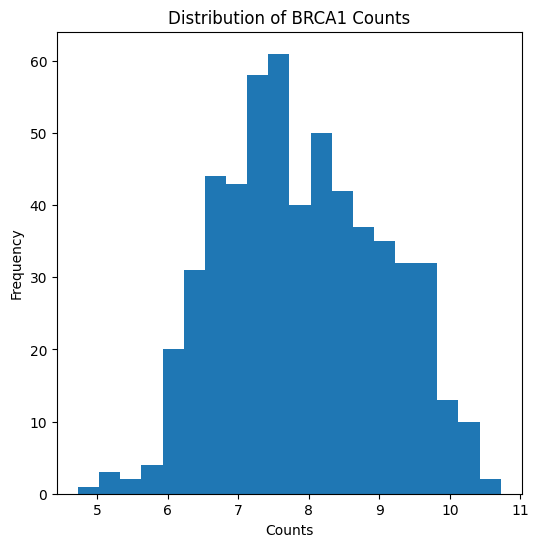

In [19]:
fig, ax = plt.subplots(figsize = (6,6))

ax.hist(x,
       bins = 20)

ax.set_title(f"Distribution of {goi} Counts")
ax.set_xlabel("Counts")
ax.set_ylabel("Frequency")

### Looking at the first 20 samples, let's look at the individual counts

In [20]:
x = train[:20]

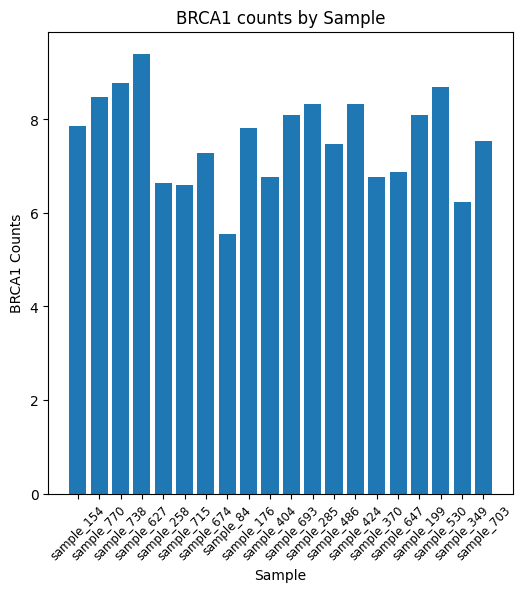

In [21]:
fig, ax = plt.subplots(figsize=(6,6))

ax.bar(x.index, height = x[goi])

ax.set_title(f"{goi} counts by Sample")
ax.set_xlabel("Sample")
ax.set_ylabel(f"{goi} Counts")

ax.tick_params("x", rotation=45, labelsize = "small")

### Do the tumor Classes have different expression of this gene?

Text(0, 0.5, 'mean BRCA1 Counts')

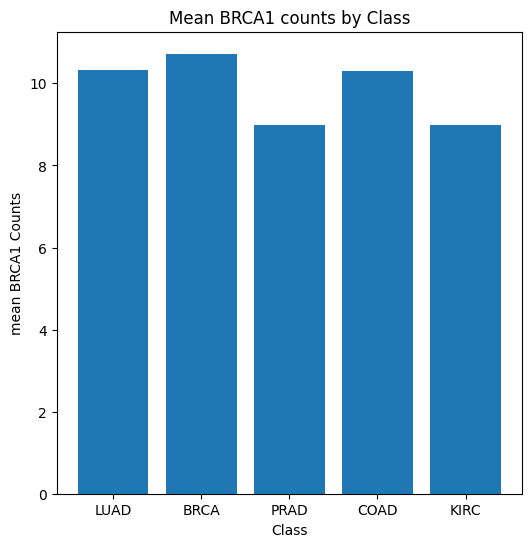

In [22]:
fig, ax = plt.subplots(figsize=(6,6))

ax.bar(train_byclass.index, height = train_byclass[goi])

ax.set_title(f"Mean {goi} counts by Class")
ax.set_xlabel("Class")
ax.set_ylabel(f"mean {goi} Counts")

This tells us the mean counts, but it isn't really informative. Let's dive a little bit deeper and look at the distribution as well as the mean

In [23]:
#first we need a list of all of the tumor types that are here
classes = list(set(train_labels["Class"].to_list()))
classes

['BRCA', 'LUAD', 'COAD', 'PRAD', 'KIRC']

Text(0.5, 0.98, 'Distribution of BRCA1 by Class')

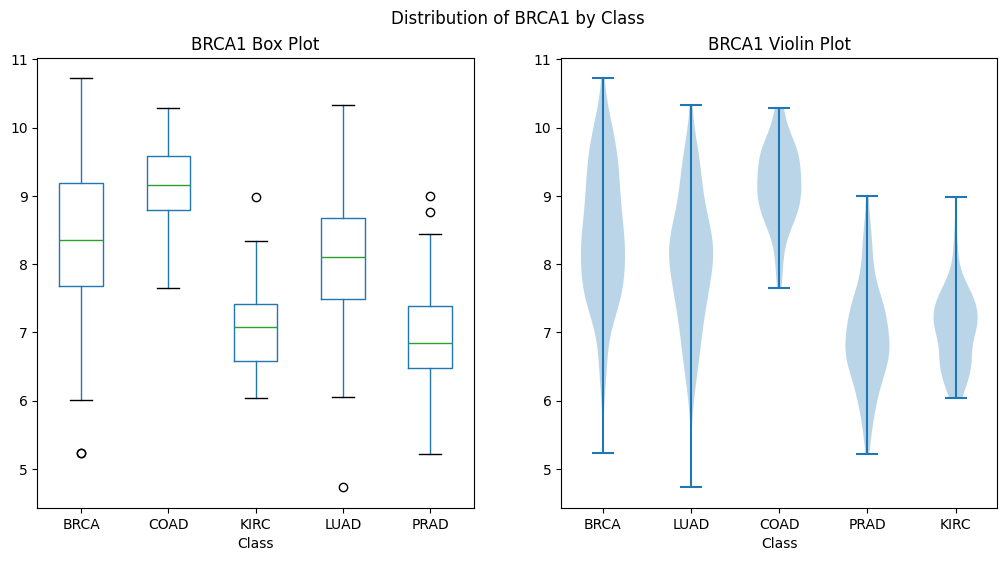

In [27]:
fig, (ax_box, ax_vln) = plt.subplots(ncols=2, figsize=(12,6))

#boxplot is a Pandas function that can be run on the Dataframe and pointed to the matplotlib "axes" object
train_byclass.boxplot(by = "Class", column =[goi], 
                               grid = False,
                              ax=ax_box)
ax_box.set_title(f"{goi} Box Plot")

#for the violin plot, we need to make list of arrays
#the list will have 5 arrays (one for each Class), each containing the counts for our Gene of Interest
dataset = [train_byclass[train_byclass.index == c][goi].values for c in classes]
ax_vln.violinplot(
    dataset=dataset
)

ax_vln.set_title(f"{goi} Violin Plot")
ax_vln.set_xlabel("Class")
ax_vln.set_xticks(ticks = list(np.arange(1,(len(classes) + 1))), labels = classes)




fig.suptitle(f"Distribution of {goi} by Class")

## Looking at multiple genes

### Building Intuition for a Heatmap

In [28]:
n_samples = 20
n_genes = 20
df = train.iloc[1:n_samples,1:n_genes].copy()
#let's grab a small subset of the data to visualize

In [42]:
#we have to pick a new gene
ex_gene = df.columns[1] #just pick one that isn't all zeros

Text(0.5, 0, 'Counts')

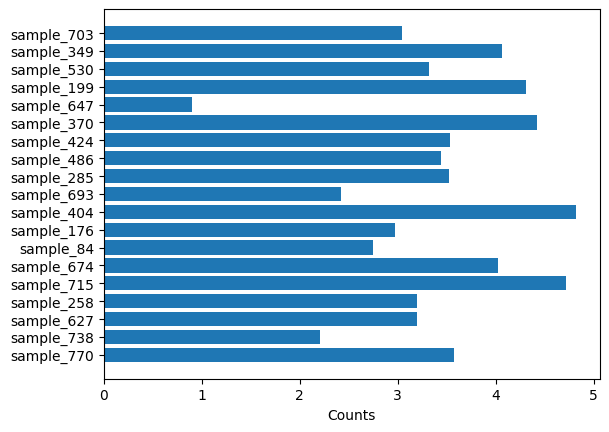

In [43]:
fig, ax = plt.subplots()

bars = ax.barh(df.index, df[ex_gene])
ax.set_xlabel("Counts")

/scratch/slurm-10075470/ipykernel_873401/3543478424.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'


Text(0.5, 0, 'Gene Counts')

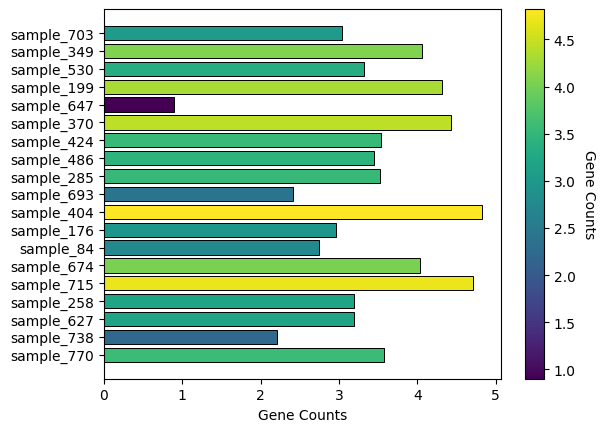

In [44]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, ax = plt.subplots()

#Create a normalization object to map data to the 0-1 range
norm = mcolors.Normalize(vmin=min(df[ex_gene]), vmax=max(df[ex_gene]))

#Choose a colormap and apply the normalized values to get colors
cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'
bar_colors = cmap(norm(df[ex_gene]))

#Plot the bars with the ex_gene counts encoded as both height and colors
bars = ax.barh(df.index, df[ex_gene], color=bar_colors, edgecolor='black', linewidth=0.7)

# Add a colorbar legend to the plot
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array required for ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Gene Counts', rotation=270, labelpad=15)

ax.set_xlabel("Gene Counts")

Here, both the height and the color are representing the gene counts

/scratch/slurm-10075470/ipykernel_873401/1653304214.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'


Text(0.5, 0, 'Gene Counts')

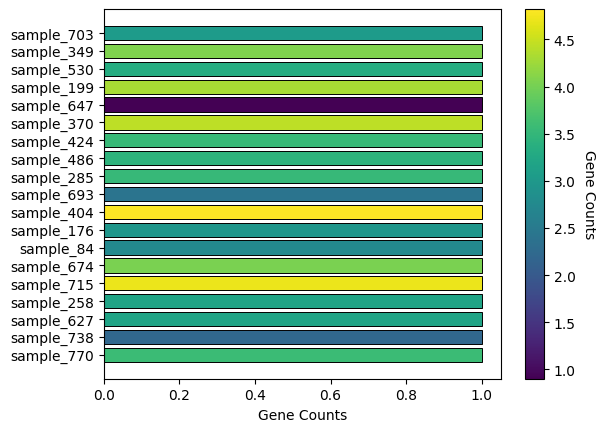

In [49]:
fig, ax = plt.subplots()

#Create a normalization object to map data to the 0-1 range
norm = mcolors.Normalize(vmin=min(df[ex_gene]), vmax=max(df[ex_gene]))

#Choose a colormap and apply the normalized values to get colors
cmap = cm.get_cmap('viridis')  # Examples: 'viridis', 'plasma', 'coolwarm', 'Blues'
bar_colors = cmap(norm(df[ex_gene]))

#Plot the bars with the ex_gene counts encoded as both height and colors
bars = ax.barh(df.index, width=1, color=bar_colors, edgecolor='black', linewidth=0.7)

# Add a colorbar legend to the plot
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Dummy array required for ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Gene Counts', rotation=270, labelpad=15)

ax.set_xlabel("Gene Counts")

<Axes: >

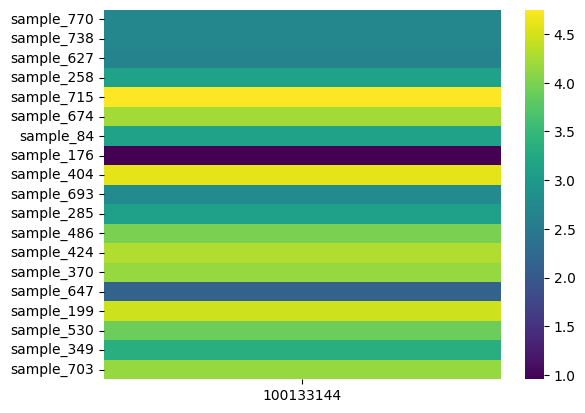

In [47]:
sns.heatmap(df.iloc[:,0:1], cmap="viridis")

<Axes: >

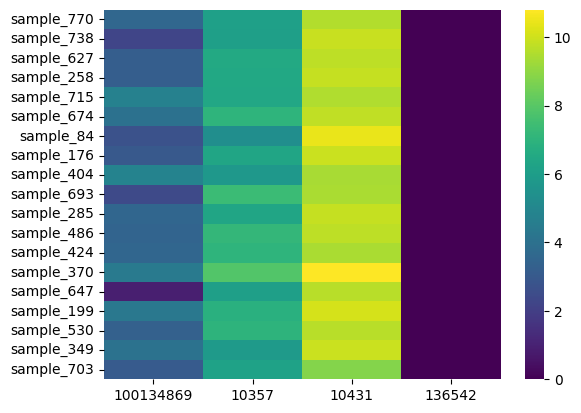

In [58]:
sns.heatmap(df.iloc[:,1:5], cmap="viridis")

<Axes: >

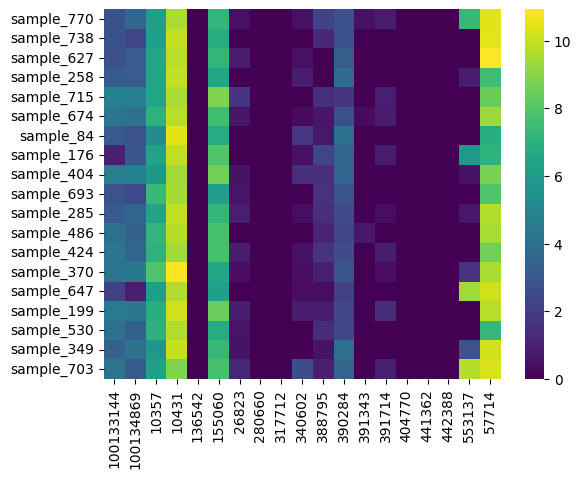

In [59]:
sns.heatmap(df, cmap="viridis")

<Axes: >

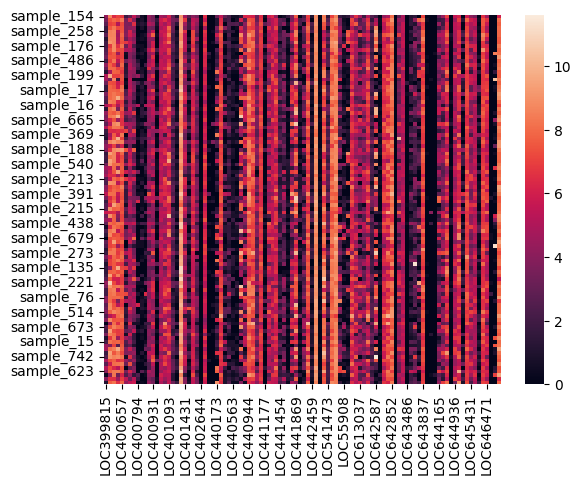

In [64]:
sns.heatmap(train.iloc[:100, 10000:10100])

## Heatmaps: Clustered vs. Unclustered

<Axes: >

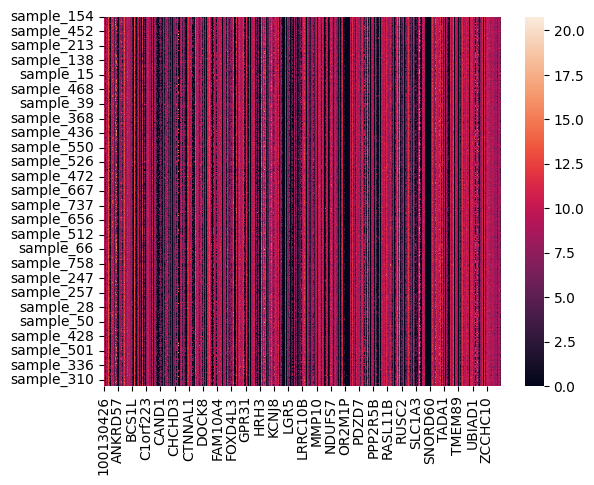

In [67]:
sns.heatmap(train)

/software/rhel9/manual/install/python/ondemand-jupyter-python3.11-2023.09/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/software/rhel9/manual/install/python/ondemand-jupyter-python3.11-2023.09/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


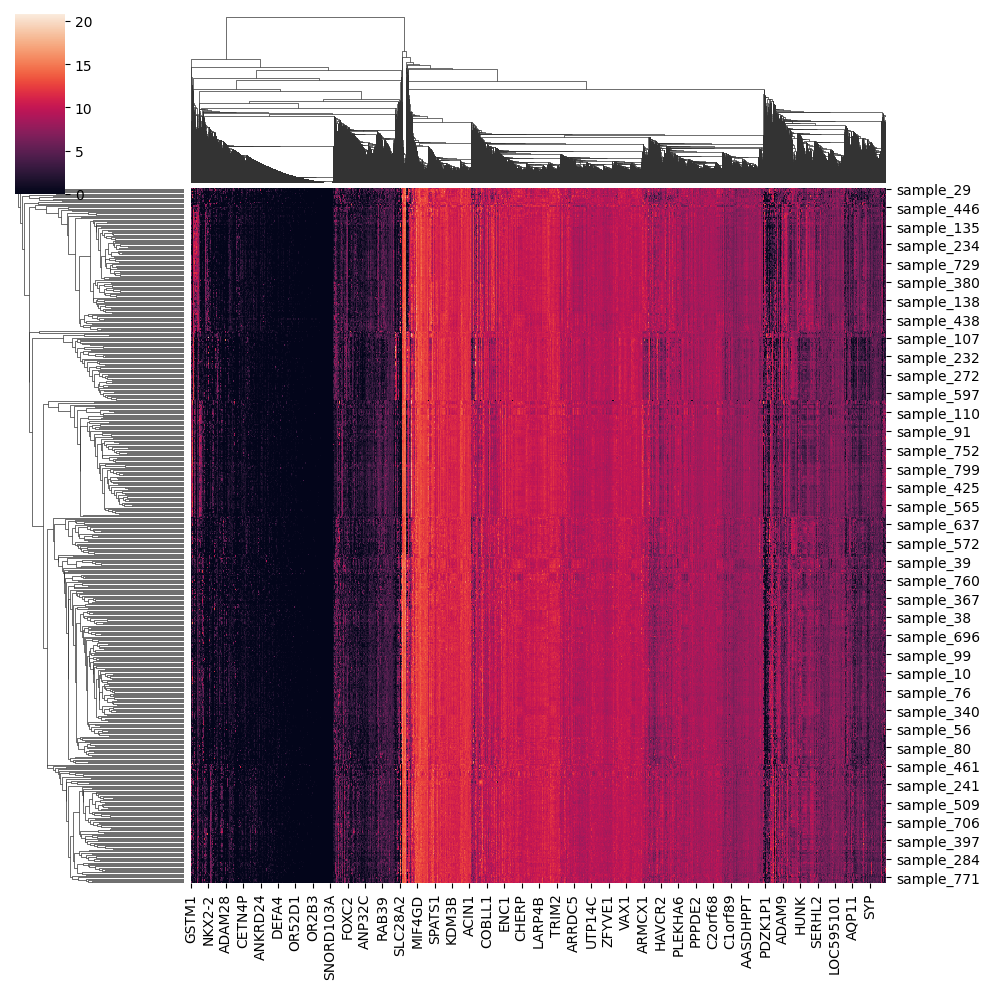

In [69]:
clustgrid = sns.clustermap(train)